<a href="https://colab.research.google.com/github/sirimadhuri02/Machine_Learning/blob/ML_course/ml6_randomforest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_excel('/content/telecom_churn.xlsx')

In [ ]:
data = data.dropna()

In [ ]:
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

In [ ]:
scaler = StandardScaler()
numerical_features = data.select_dtypes(include=['float64', 'int64']).columns
data[numerical_features] = scaler.fit_transform(data[numerical_features])

In [ ]:
X = data.drop(columns=['Churn'])
y = data['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
randomforest_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
randomforest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = randomforest_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [ ]:
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.00
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

Classification Report:
               precision    recall  f1-score   support

        -1.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



<ipython-input-22-1b0f2e0297b6>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df,palette='RdBu')


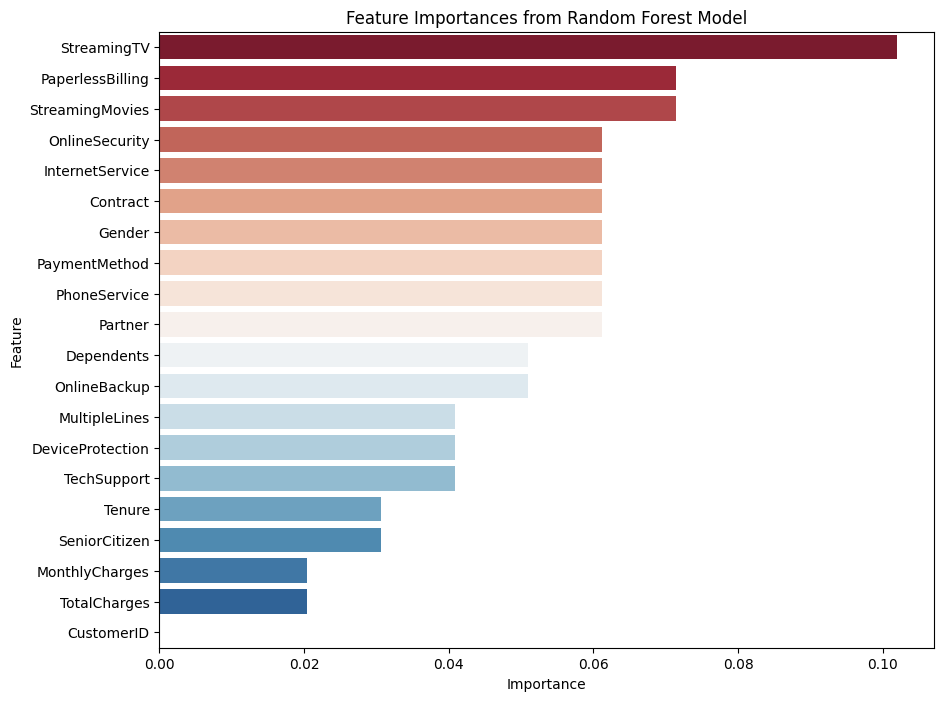

In [ ]:
feature_importances = randomforest_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df,palette='RdBu')
plt.title('Feature Importances from Random Forest Model')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

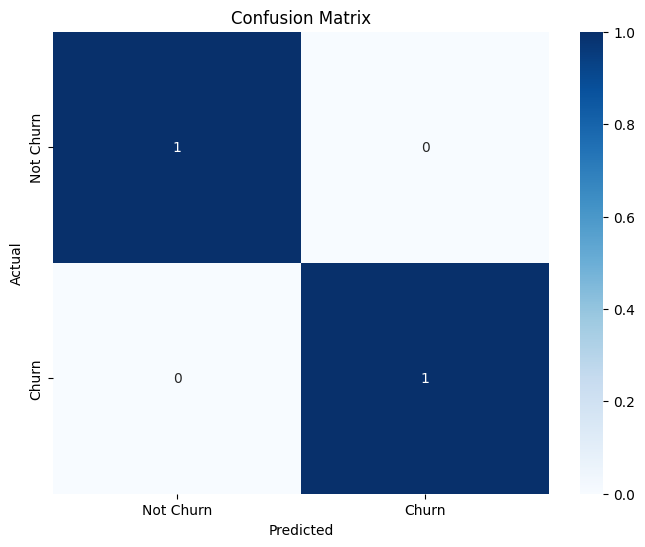

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

Model Performance Metrics:
Accuracy: 0.68
Precision: 0.42
Recall: 0.18
F1 Score: 0.25


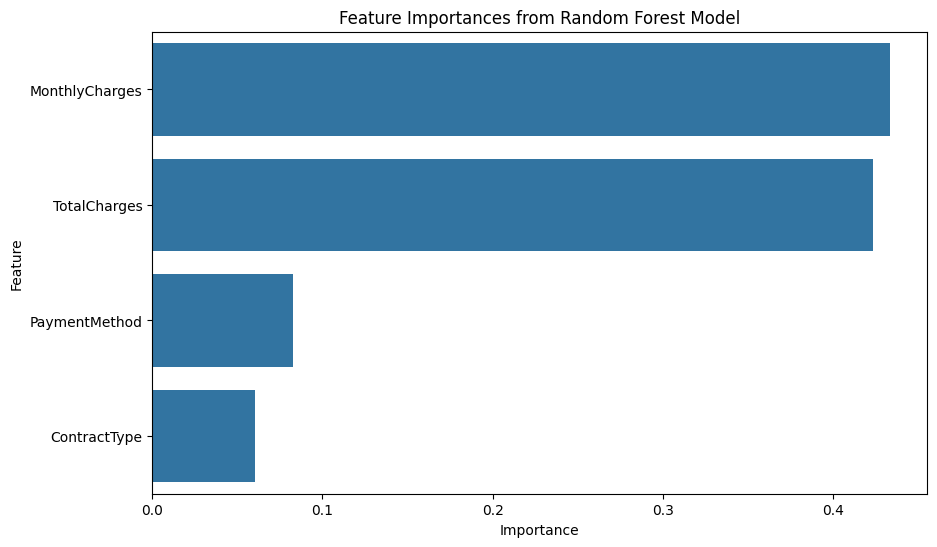

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Generate Synthetic Data
np.random.seed(0)

# Number of samples
num_samples = 1000

# Generate random data for features
monthly_charges = np.random.uniform(20, 100, num_samples)
total_charges = monthly_charges * np.random.randint(1, 24, num_samples)  # simulate higher charges for longer customers
contract_type = np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], num_samples)
payment_method = np.random.choice(['Electronic Check', 'Mailed Check', 'Bank Transfer', 'Credit Card'], num_samples)
churn = np.random.choice(['Yes', 'No'], num_samples, p=[0.3, 0.7])  # Assuming a 30% churn rate

# Create DataFrame
data = pd.DataFrame({
    'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges,
    'ContractType': contract_type,
    'PaymentMethod': payment_method,
    'Churn': churn
})

# Step 2: Preprocess the Data
# Convert categorical variables to numeric using Label Encoding
label_encoders = {}
for column in ['ContractType', 'PaymentMethod', 'Churn']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# Split features and target
X = data.drop(columns=['Churn'])
y = data['Churn']

# Normalize numerical features
scaler = StandardScaler()
X[['MonthlyCharges', 'TotalCharges']] = scaler.fit_transform(X[['MonthlyCharges', 'TotalCharges']])

# Step 3: Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Build and Train Random Forest Classifier
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Step 5: Make Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Step 7: Visualize Feature Importances
feature_importances = model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title("Feature Importances from Random Forest Model")
plt.show()


In [ ]:
import numpy as np
A = np.arange(12).reshape(3,4)
B = np.array([1,2,3])
C = A[:,::2]
D = B[:, None] * C
print(D.shape)
print(D)

(3, 2)
[[ 0  2]
 [ 8 12]
 [24 30]]


In [ ]:
for i in range(5):
  if i %2 == 0:
    break
else:
    print("Done")
print("Finished")


Finished


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dates = pd.date_range('2025-01-01',periods = 90)
temp = pd.Series(15 + 10 * np.sin(np.linspace(0, 3*np.pi,90)),index=dates)
df = pd.DataFrame({'temp': temps})

NameError: name 'temps' is not defined

In [ ]:
my_list = [10,20,30]
my_dict = {'x':10,'y':20,'z':30}